In [1]:
import numpy as np
import matplotlib.pyplot as plt

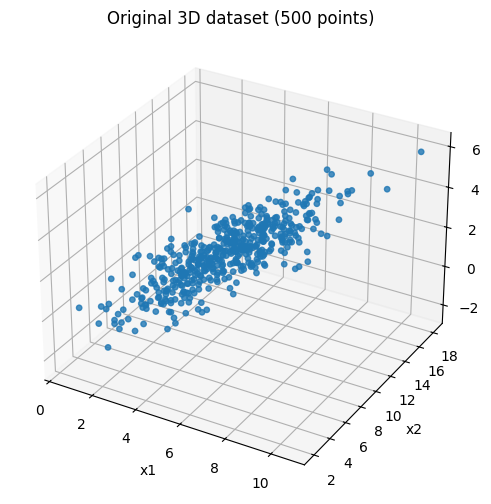

Eigenvalues (descending): [9.48426072 3.77112111 0.43753844]
Eigenvectors shape: (3, 3)


In [2]:
#----------------------------------EX1-------------------------------------

np.random.seed(42)

mu = np.array([5, 10, 2])
Sigma = np.array([[3, 2, 2],
                  [2, 10, 1],
                  [2, 1, 2]])


X = np.random.multivariate_normal(mean=mu, cov=Sigma, size=500)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], s=15, alpha=0.8)
ax.set_title("Original 3D dataset (500 points)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
plt.show()

X_mean = X.mean(axis=0)
Xc = X - X_mean

N = Xc.shape[0]
Cov = (Xc.T @ Xc) / N

eigvals, eigvecs = np.linalg.eigh(Cov)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Eigenvalues (descending):", eigvals)
print("Eigenvectors shape:", eigvecs.shape)


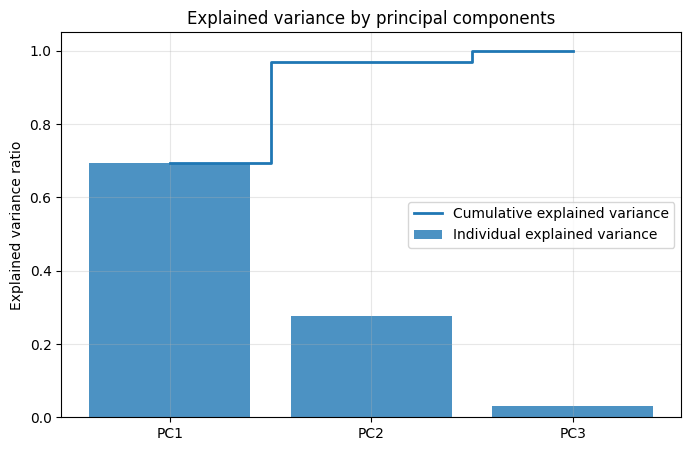

In [3]:
explained = eigvals / np.sum(eigvals)
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.bar([1,2,3], explained, alpha=0.8, label="Individual explained variance")
plt.step([1,2,3], cum_explained, where="mid", linewidth=2, label="Cumulative explained variance")
plt.xticks([1,2,3], ["PC1", "PC2", "PC3"])
plt.ylim(0, 1.05)
plt.title("Explained variance by principal components")
plt.ylabel("Explained variance ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
def plot_anomalies_3d(X, y_pred, title):

    inliers = (y_pred == 0)
    outliers = (y_pred == 1)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[inliers,0], X[inliers,1], X[inliers,2], s=15, alpha=0.7, label="Inliers")
    ax.scatter(X[outliers,0], X[outliers,1], X[outliers,2], s=25, alpha=0.9, label="Outliers")

    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
    ax.legend()
    plt.show()


PC3 threshold: 1.0853753262580923 | #outliers: 50


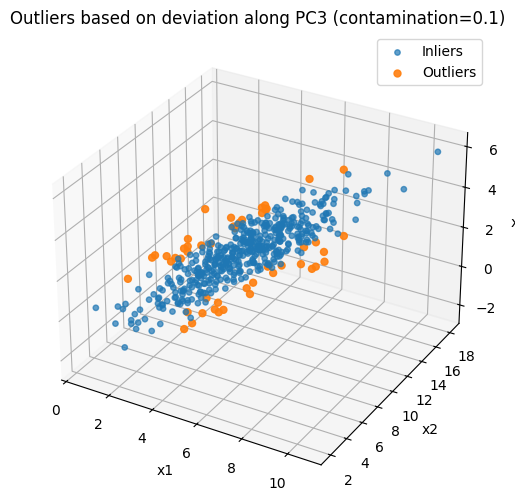

In [5]:
contamination = 0.1

Z = Xc @ eigvecs  
pc3 = Z[:, 2]
dev3 = np.abs(pc3 - pc3.mean())

thr3 = np.quantile(dev3, 1 - contamination)  
y_pc3 = (dev3 > thr3).astype(int)

print("PC3 threshold:", thr3, "| #outliers:", y_pc3.sum())
plot_anomalies_3d(X, y_pc3, "Outliers based on deviation along PC3 (contamination=0.1)")


PC2 threshold: 3.0891989236610233 | #outliers: 50


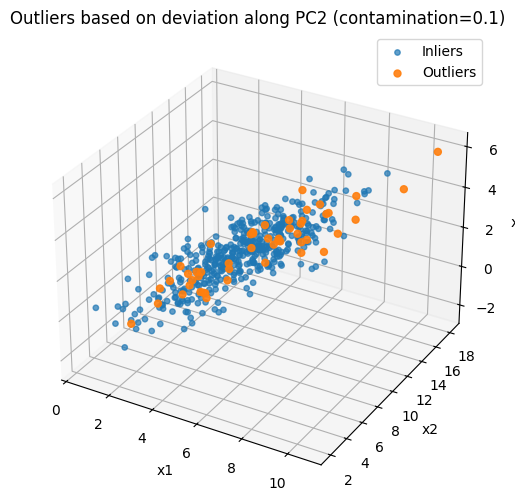

In [6]:
pc2 = Z[:, 1]
dev2 = np.abs(pc2 - pc2.mean())

thr2 = np.quantile(dev2, 1 - contamination)
y_pc2 = (dev2 > thr2).astype(int)

print("PC2 threshold:", thr2, "| #outliers:", y_pc2.sum())
plot_anomalies_3d(X, y_pc2, "Outliers based on deviation along PC2 (contamination=0.1)")


Distance threshold: 6.2488838420079995 | #outliers: 50


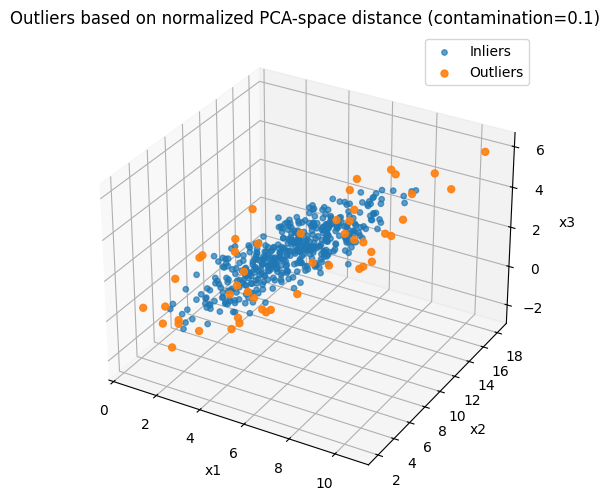

In [7]:
Z_norm = Z / np.sqrt(eigvals)  

cent = Z_norm.mean(axis=0)

dist2 = np.sum((Z_norm - cent) ** 2, axis=1)

thr_dist = np.quantile(dist2, 1 - contamination)
y_dist = (dist2 > thr_dist).astype(int)

print("Distance threshold:", thr_dist, "| #outliers:", y_dist.sum())
plot_anomalies_3d(X, y_dist, "Outliers based on normalized PCA-space distance (contamination=0.1)")


Loaded: (49097, 9) (49097,)
Raw labels unique: [0 1]
Outlier rate (overall): 0.0715114976475141
Train: (19638, 9) Test: (29459, 9)
Train contamination: 0.07149404216315307


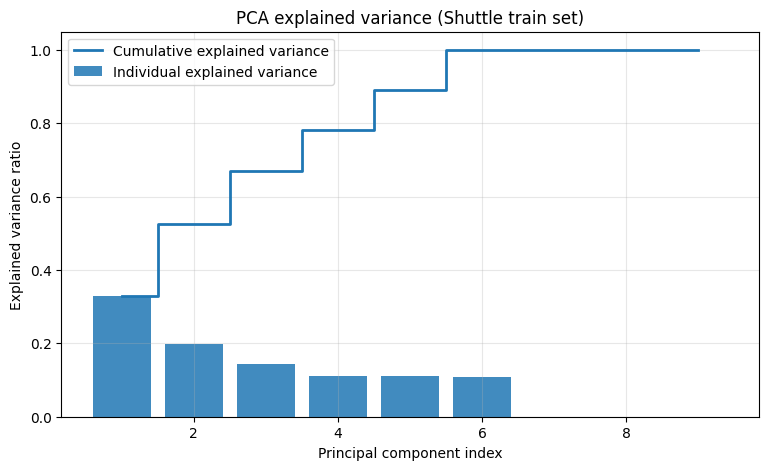

PCA - Balanced Accuracy (train): 0.9746859206385365
PCA - Balanced Accuracy (test):  0.9739297121407451


In [ ]:
#----------------------------------EX2-------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

from pyod.utils.utility import standardizer
from pyod.models.pca import PCA
from pyod.models.kpca import KPCA

mat = loadmat("shuttle 1.mat")

if "X" in mat and "y" in mat:
    X = mat["X"]
    y_raw = mat["y"].ravel()
else:
    candidates = {k: v for k, v in mat.items() if not k.startswith("__")}
    X, y_raw = None, None

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.ndim == 2 and v.shape[0] > 10 and v.shape[1] > 1:
            X = v
            break

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.size == X.shape[0]:
            y_raw = v.ravel()
            break

    if X is None or y_raw is None:
        raise ValueError(f"Could not infer X/y from keys: {list(candidates.keys())}")

print("Loaded:", X.shape, y_raw.shape)
print("Raw labels unique:", np.unique(y_raw)[:10])

uniq = set(np.unique(y_raw).tolist())

if uniq == {-1, 1}:
    y = ((-1 * y_raw + 1) / 2).astype(int)
elif uniq == {1, 2}:
    y = (y_raw == 2).astype(int)
else:
    y = y_raw.astype(int)

print("Outlier rate (overall):", float(np.mean(y)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42, stratify=y
)
contamination_train = float(np.mean(y_train))
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train contamination:", contamination_train)

X_train_s, X_test_s = standardizer(X_train, X_test)

pca = PCA(contamination=contamination_train, random_state=42)
pca.fit(X_train_s)

ev = pca.explained_variance_
ev = np.array(ev, dtype=float)

ev_ratio = ev / ev.sum()
cum_ev = np.cumsum(ev_ratio)

plt.figure(figsize=(9, 5))
plt.bar(np.arange(1, len(ev_ratio) + 1), ev_ratio, alpha=0.85, label="Individual explained variance")
plt.step(np.arange(1, len(cum_ev) + 1), cum_ev, where="mid", linewidth=2, label="Cumulative explained variance")
plt.title("PCA explained variance (Shuttle train set)")
plt.xlabel("Principal component index")
plt.ylabel("Explained variance ratio")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

y_train_pred_pca = pca.predict(X_train_s)  
y_test_pred_pca  = pca.predict(X_test_s)   

ba_train_pca = balanced_accuracy_score(y_train, y_train_pred_pca)
ba_test_pca  = balanced_accuracy_score(y_test, y_test_pred_pca)

print("PCA - Balanced Accuracy (train):", ba_train_pca)
print("PCA - Balanced Accuracy (test): ", ba_test_pca)

kpca = KPCA(contamination=contamination_train, kernel="rbf")
kpca.fit(X_train_s)

y_train_pred_kpca = kpca.predict(X_train_s)
y_test_pred_kpca  = kpca.predict(X_test_s)

ba_train_kpca = balanced_accuracy_score(y_train, y_train_pred_kpca)
ba_test_kpca  = balanced_accuracy_score(y_test, y_test_pred_kpca)

print("KPCA - Balanced Accuracy (train):", ba_train_kpca)
print("KPCA - Balanced Accuracy (test): ", ba_test_kpca)


In [6]:
import sys
print(sys.version)

3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)]


In [7]:
import sys
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install tensorflow

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 12.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


Loaded: (49097, 9) | outlier rate: 0.0715114976475141
Train range: 0.0 1.0
Test  range: 0.0 0.9934640526771545
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0206 - val_loss: 0.0186
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0171 - val_loss: 0.0154
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136 - val_loss: 0.0117
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 - val_loss: 0.0083
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0072 - val_loss: 0.0063
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 - val_loss: 0.0046
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━

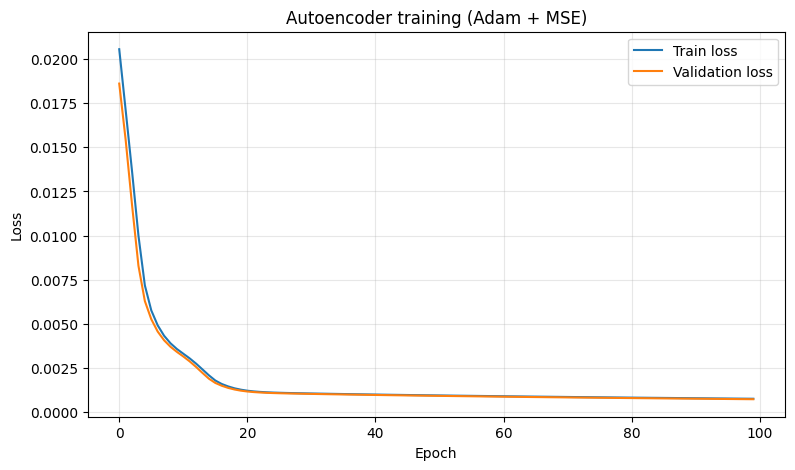

In [3]:
#----------------------------------EX3-------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

mat = loadmat("shuttle 1.mat")

if "X" in mat and "y" in mat:
    X = mat["X"]
    y_raw = mat["y"].ravel()
else:
    candidates = {k: v for k, v in mat.items() if not k.startswith("__")}
    X, y_raw = None, None

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.ndim == 2 and v.shape[0] > 10 and v.shape[1] > 1:
            X = v
            break

    for k, v in candidates.items():
        if isinstance(v, np.ndarray) and v.size == X.shape[0]:
            y_raw = v.ravel()
            break

    if X is None or y_raw is None:
        raise ValueError(f"Could not infer X/y from keys: {list(candidates.keys())}")

uniq = set(np.unique(y_raw).tolist())
if uniq == {-1, 1}:
    y = ((-1 * y_raw + 1) / 2).astype(int)
elif uniq == {1, 2}:
    y = (y_raw == 2).astype(int)
else:
    y = y_raw.astype(int)

print("Loaded:", X.shape, "| outlier rate:", float(np.mean(y)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

xmin = X_train.min(axis=0, keepdims=True)
xmax = X_train.max(axis=0, keepdims=True)
den = xmax - xmin
den[den == 0] = 1.0  

X_train_mm = (X_train - xmin) / den
X_test_mm  = (X_test  - xmin) / den

X_train_mm = tf.clip_by_value(X_train_mm, 0.0, 1.0).numpy()
X_test_mm  = tf.clip_by_value(X_test_mm,  0.0, 1.0).numpy()

print("Train range:", float(X_train_mm.min()), float(X_train_mm.max()))
print("Test  range:", float(X_test_mm.min()),  float(X_test_mm.max()))

class Autoencoder(keras.Model):
    def __init__(self, input_dim: int):
        super().__init__()
        self.encoder = keras.Sequential(
            [
                layers.Input(shape=(input_dim,)),
                layers.Dense(8, activation="relu"),
                layers.Dense(5, activation="relu"),
                layers.Dense(3, activation="relu"),
            ],
            name="encoder",
        )
        self.decoder = keras.Sequential(
            [
                layers.Input(shape=(3,)),
                layers.Dense(5, activation="relu"),
                layers.Dense(8, activation="relu"),
                layers.Dense(input_dim, activation="sigmoid"),
            ],
            name="decoder",
        )

    def call(self, inputs, training=False):
        z = self.encoder(inputs, training=training)
        xhat = self.decoder(z, training=training)
        return xhat

input_dim = X_train_mm.shape[1]
ae = Autoencoder(input_dim)

ae.compile(optimizer="adam", loss="mse")

history = ae.fit(
    X_train_mm, X_train_mm,
    epochs=100,
    batch_size=1024,
    shuffle=True,
    validation_data=(X_test_mm, X_test_mm),
    verbose=1
)

plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Autoencoder training (Adam + MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


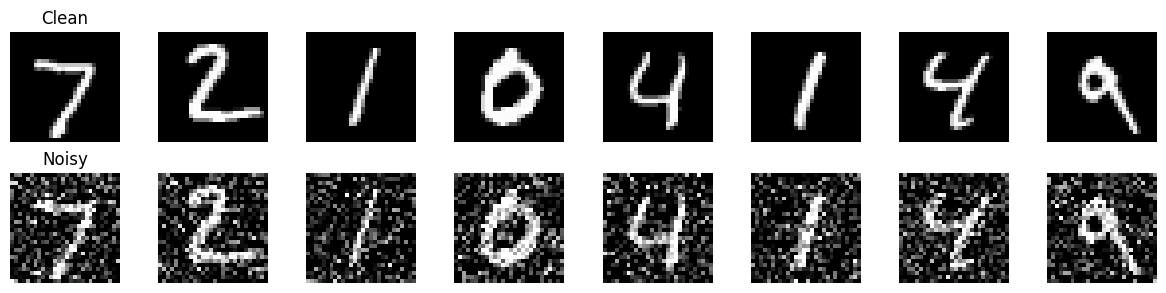

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1357 - val_loss: 0.1142
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0907 - val_loss: 0.0465
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0250 - val_loss: 0.0147
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0131 - val_loss: 0.0116
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0112 - val_loss: 0.0106
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0106 - val_loss: 0.0102
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0100 - val_loss: 0.0097
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0098 - val_loss: 0.0095
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0096 - val_loss: 0.0094


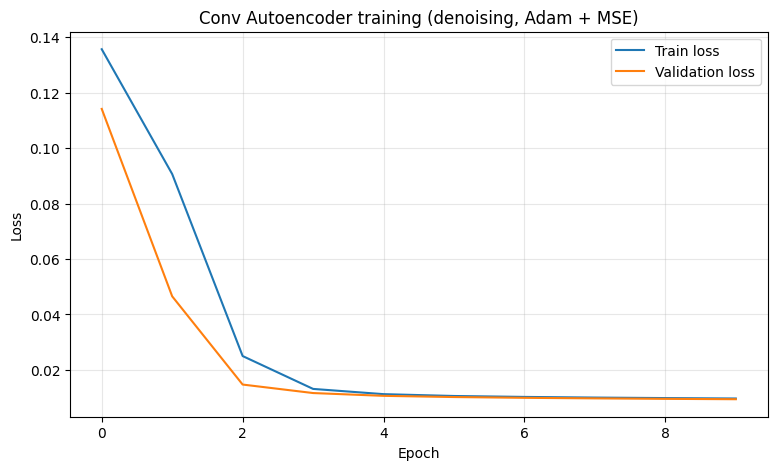

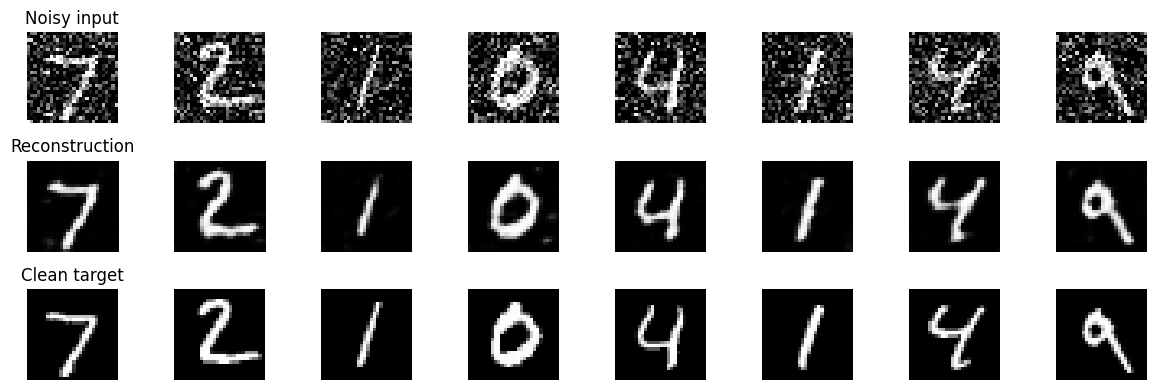

In [4]:
#----------------------------------EX4-------------------------------------

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print("Train:", x_train.shape, "Test:", x_test.shape)

noise_factor = 0.35
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=tf.shape(x_train))
x_test_noisy  = x_test  + noise_factor * tf.random.normal(shape=tf.shape(x_test))

x_train_noisy = tf.clip_by_value(x_train_noisy, 0.0, 1.0)
x_test_noisy  = tf.clip_by_value(x_test_noisy,  0.0, 1.0)

n = 8
plt.figure(figsize=(12, 3))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Clean")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Noisy")
plt.tight_layout()
plt.show()

# convolutional autoencoder 

class ConvAutoencoder(keras.Model):
    def __init__(self):
        super().__init__()

        self.encoder = keras.Sequential(
            [
                layers.Input(shape=(28, 28, 1)),
                layers.Conv2D(8, (3, 3), activation="relu", strides=2, padding="same"),
                layers.Conv2D(4, (3, 3), activation="relu", strides=2, padding="same"),
            ],
            name="encoder",
        )

        self.decoder = keras.Sequential(
            [
                layers.Input(shape=(7, 7, 4)),
                layers.Conv2DTranspose(4, (3, 3), activation="relu", strides=2, padding="same"),
                layers.Conv2DTranspose(8, (3, 3), activation="relu", strides=2, padding="same"),
                layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same"),
            ],
            name="decoder",
        )

    def call(self, x, training=False):
        z = self.encoder(x, training=training)
        xhat = self.decoder(z, training=training)
        return xhat

cae = ConvAutoencoder()
cae.compile(optimizer="adam", loss="mse")

history = cae.fit(
    x_train_noisy, x_train,
    epochs=10,             
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Conv Autoencoder training (denoising, Adam + MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

recon = cae.predict(x_test_noisy[:n], verbose=0)

plt.figure(figsize=(12, 4))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Noisy input")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(recon[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Reconstruction")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Clean target")
plt.tight_layout()
plt.show()
